# K Means Clustering

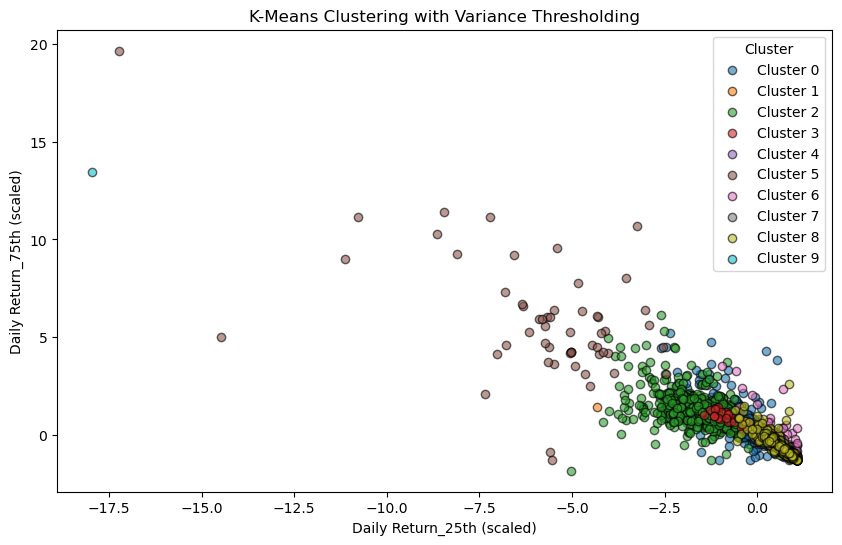

Clusters have been saved to dataset/stock_clusters.csv


In [24]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the data
data_path = 'summary_statistics_2015_2017.csv'
data = pd.read_csv(data_path)

# Drop rows with any NaN values
data.dropna(inplace=True)

# Select numeric features
numeric_data = data.select_dtypes(include=[float, int])

# Apply Variance Thresholding for feature selection
threshold = 0.1  # Adjust this value based on your data
selector = VarianceThreshold(threshold=threshold)
selected_data = selector.fit_transform(numeric_data)

# Get the selected feature names after variance thresholding
selected_features = numeric_data.columns[selector.get_support()]

# Standardize the selected features
scaler = StandardScaler()
data_scaled = scaler.fit_transform(selected_data)

# Perform K-means clustering
n_clusters = 10  # Adjust based on your preference
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

# Add clusters back to the original data for reference
data['Cluster'] = clusters

# Visualization of clusters using the first two selected features with lighter opacity and legend
plt.figure(figsize=(10, 6))

# Plot each cluster separately
for cluster in range(n_clusters):
    cluster_data = data_scaled[clusters == cluster]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], label=f"Cluster {cluster}", alpha=0.6, edgecolor='k')

plt.title('K-Means Clustering with Variance Thresholding')
plt.xlabel(f'{selected_features[0]} (scaled)')
plt.ylabel(f'{selected_features[1]} (scaled)')
plt.legend(title="Cluster")
plt.show()

# Save the data with clusters to a CSV file
output_path = 'dataset/stock_clusters.csv'
data.to_csv(output_path, index=False)

print(f"Clusters have been saved to {output_path}")



Feature variances (ascending order):
 Log Returns_50th      3.898873e-06
Log Returns_75th      7.818111e-05
Log Returns_25th      1.287399e-04
Daily Return_50th     3.803951e-02
Close-Open_50th       5.019187e-02
Close-Open_75th       6.325796e-01
Daily Return_75th     8.308132e-01
Close-Open_25th       9.861496e-01
Daily Return_25th     1.193178e+00
Volatility-10_25th    1.875736e+00
High-Low_25th         2.091172e+00
Volatility-10_50th    4.503412e+00
ROC-10_50th           4.861875e+00
High-Low_50th         5.094675e+00
Volatility-10_75th    1.474133e+01
High-Low_75th         1.662151e+01
ROC-10_25th           1.669906e+01
RSI_50th              2.341975e+01
RSI_75th              2.843670e+01
RSI_25th              2.971195e+01
ROC-10_75th           6.057262e+01
MA-10_25th            6.637783e+06
EMA_25th              6.666668e+06
MA-10_50th            1.194581e+08
EMA_50th              1.358304e+08
MA-10_75th            1.311399e+09
EMA_75th              1.796576e+09
Volume MA-20_25th

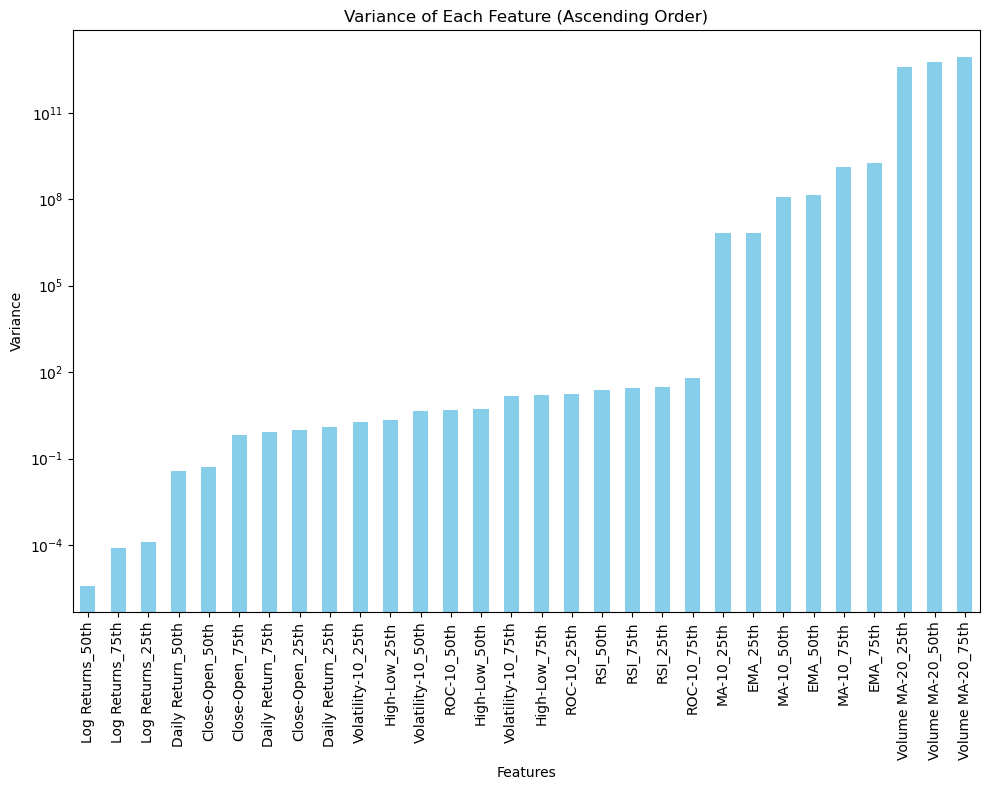

In [ ]:
# Load the data
data_path = 'summary_statistics_2015_2017.csv'
data = pd.read_csv(data_path)

# Drop rows with any NaN values
data.dropna(inplace=True)

# Select numeric features
numeric_data = data.select_dtypes(include=[float, int])

# Calculate variance of each feature
feature_variances = numeric_data.var()
feature_variances_sorted = feature_variances.sort_values(ascending=True)

# Print the sorted variances
print("Feature variances (ascending order):\n", feature_variances_sorted)

# Plot the variances in ascending order
plt.figure(figsize=(10, 8))
feature_variances_sorted.plot(kind='bar', color='skyblue')
plt.title('Variance of Each Feature (Ascending Order)')
plt.xlabel('Features')
plt.ylabel('Variance')
plt.yscale('log')  # Use a log scale for better visibility of smaller variances
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()




In [17]:
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Define the thresholds to test
tested_thresholds = [0.1, 0.3, 0.5, 0.8]
best_threshold = 0
best_score = -1
threshold_scores = {}

for threshold in tested_thresholds:
    selector = VarianceThreshold(threshold=threshold)
    selected_data = selector.fit_transform(numeric_data)
    selected_features = numeric_data.columns[selector.get_support()]
    
    # Standardize the selected features
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(selected_data)

    # Perform K-means clustering
    kmeans = KMeans(n_clusters=15, random_state=42)
    clusters = kmeans.fit_predict(data_scaled)

    # Evaluate clustering quality using silhouette score
    score = silhouette_score(data_scaled, clusters)
    threshold_scores[threshold] = score
    print(f"Threshold: {threshold}, Silhouette Score: {score}")

    # Update the best score and threshold if the current score is better
    if score > best_score:
        best_score = score
        best_threshold = threshold

print(f"Best threshold: {best_threshold} with Silhouette Score: {best_score}")
print("Threshold scores:", threshold_scores)


Threshold: 0.1, Silhouette Score: 0.2355703744195536
Threshold: 0.3, Silhouette Score: 0.2355703744195536
Threshold: 0.5, Silhouette Score: 0.2355703744195536
Threshold: 0.8, Silhouette Score: 0.22966481301054686
Best threshold: 0.1 with Silhouette Score: 0.2355703744195536
Threshold scores: {0.1: 0.2355703744195536, 0.3: 0.2355703744195536, 0.5: 0.2355703744195536, 0.8: 0.22966481301054686}


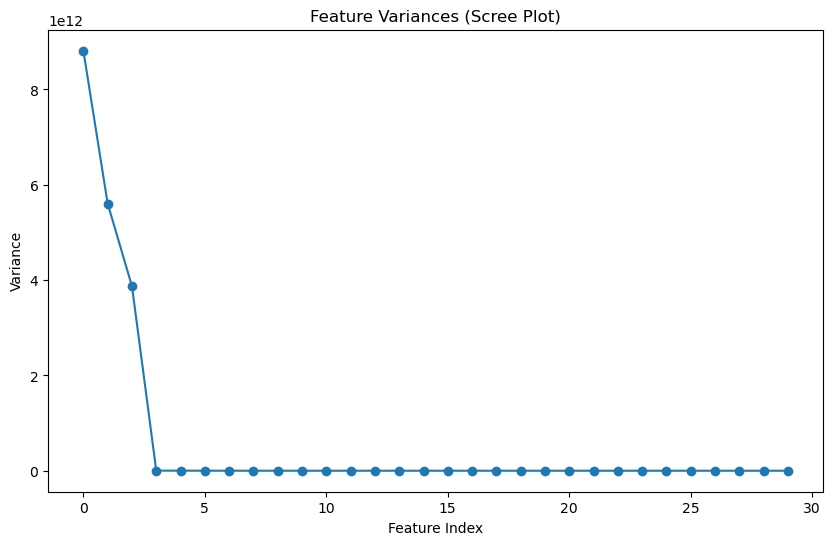

In [18]:
# Plot variances of all features to identify the elbow point
plt.figure(figsize=(10, 6))
plt.plot(range(len(feature_variances_sorted)), feature_variances_sorted.values, marker='o')
plt.xlabel('Feature Index')
plt.ylabel('Variance')
plt.title('Feature Variances (Scree Plot)')
plt.show()


/var/folders/8l/9f8bkrp10_j_nv1019x4c4lr0000gn/T/ipykernel_34142/4204250679.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_no_outliers['Cluster'] = clusters


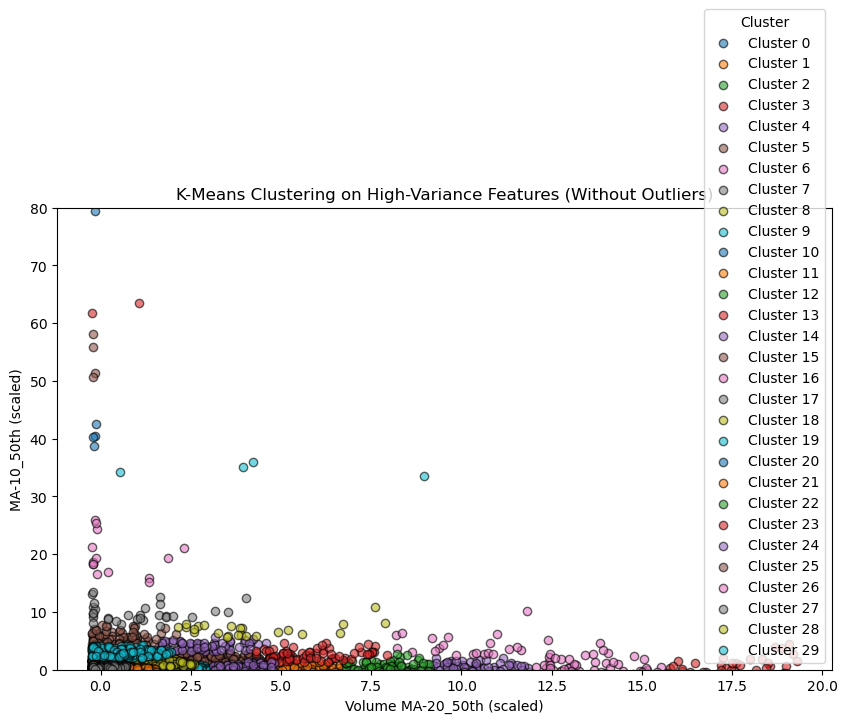

/var/folders/8l/9f8bkrp10_j_nv1019x4c4lr0000gn/T/ipykernel_34142/4204250679.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_no_outliers['Cluster'] = clusters


Clustered data with labels saved to clustered_data.csv


In [57]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from scipy.stats import zscore
import pandas as pd

# Load the data
data_path = 'summary_statistics_2015_2017.csv'
data = pd.read_csv(data_path)
data.dropna(inplace=True)

# Select specific high-variance features
selected_features = ['Volume MA-20_50th', 'MA-10_50th']
data_selected = data[selected_features]

# Remove outliers
data_no_outliers = data[(zscore(data[selected_features]) < 3).all(axis=1)]
data_selected_no_outliers = data_no_outliers[selected_features]

# Apply RobustScaler
scaler = RobustScaler()
data_scaled = scaler.fit_transform(data_selected_no_outliers)

# Perform K-means clustering with fewer clusters
n_clusters = 30  # Adjust based on results
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

# Add clusters back to the original data for reference
data_no_outliers['Cluster'] = clusters

# Visualization with lighter opacity and legend
plt.figure(figsize=(10, 6))
for cluster in range(n_clusters):
    cluster_data = data_scaled[clusters == cluster]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], label=f"Cluster {cluster}", alpha=0.6, edgecolor='k')

plt.title('K-Means Clustering on High-Variance Features (Without Outliers)')
plt.xlabel(f'{selected_features[0]} (scaled)')
plt.ylabel(f'{selected_features[1]} (scaled)')
plt.ylim(0, 80)
plt.legend(title="Cluster")
plt.show()

# Add clusters back to the original data for reference
data_no_outliers['Cluster'] = clusters

# Write the output to a CSV file
output_path = 'clustered_data.csv'
data_no_outliers.to_csv(output_path, index=False)

print(f"Clustered data with labels saved to {output_path}")


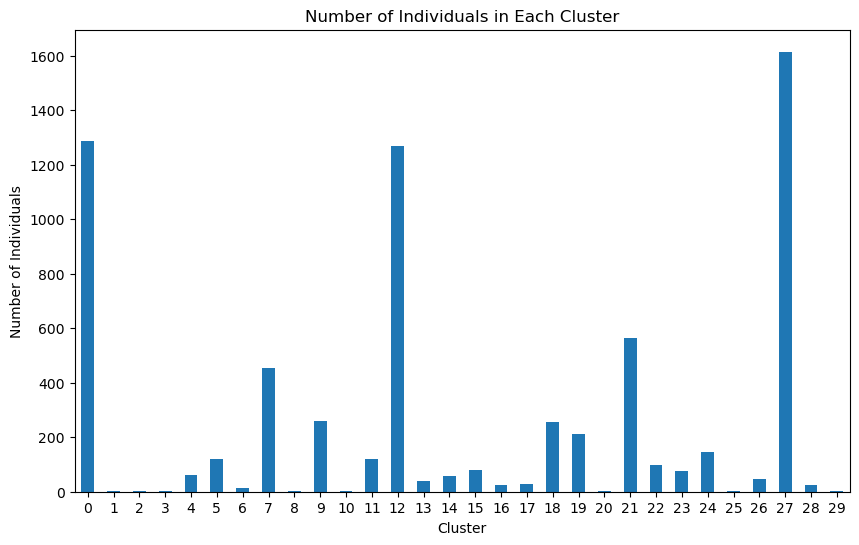

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
file_path = 'clustered_data.csv'
stock_clusters_df = pd.read_csv(file_path)

# Count the number of individuals in each cluster
cluster_counts = stock_clusters_df['Cluster'].value_counts().sort_index()

# Plot the cluster counts
plt.figure(figsize=(10, 6))
cluster_counts.plot(kind='bar')
plt.title('Number of Individuals in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=0)
plt.show()



In [ ]:
## Grab 3 stocks from cluster 4
cluster_4_stocks = stock_clusters_df[stock_clusters_df['Cluster'] == 4].head(3)

# Display the selected stocks
cluster_4_stocks[['Ticker', 'Cluster']]


,Ticker,Cluster
9,sfun,4
270,yum,4
471,viab,4


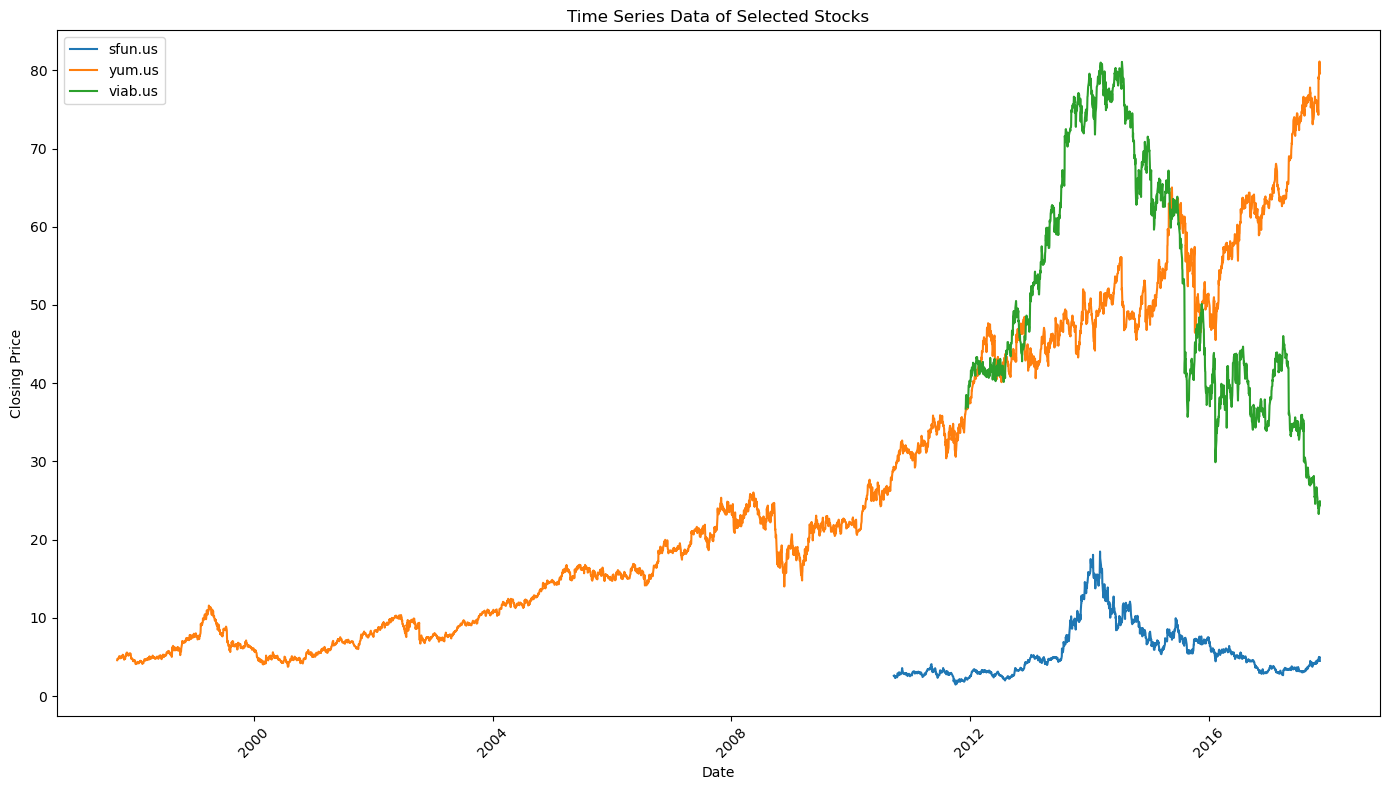

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# Load each time series data file for plotting
files = {
    'sfun.us': 'dataset/stock_csv/sfun.us.csv',
    'yum.us': 'dataset/stock_csv/yum.us.csv',
    'viab.us': 'dataset/stock_csv/viab.us.csv'
}

# Initialize a plot
plt.figure(figsize=(14, 8))

# Plot each stock's time series data
for label, file_path in files.items():
    stock_data = pd.read_csv(file_path)
    
    # Convert 'Date' to datetime format and sort by date
    stock_data['Date'] = pd.to_datetime(stock_data['Date'])
    stock_data = stock_data.sort_values('Date')
    
    # Plot the data if 'Close' column exists
    if 'Close' in stock_data.columns:
        plt.plot(stock_data['Date'], stock_data['Close'], label=label)

# Format the plot
plt.title("Time Series Data of Selected Stocks")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



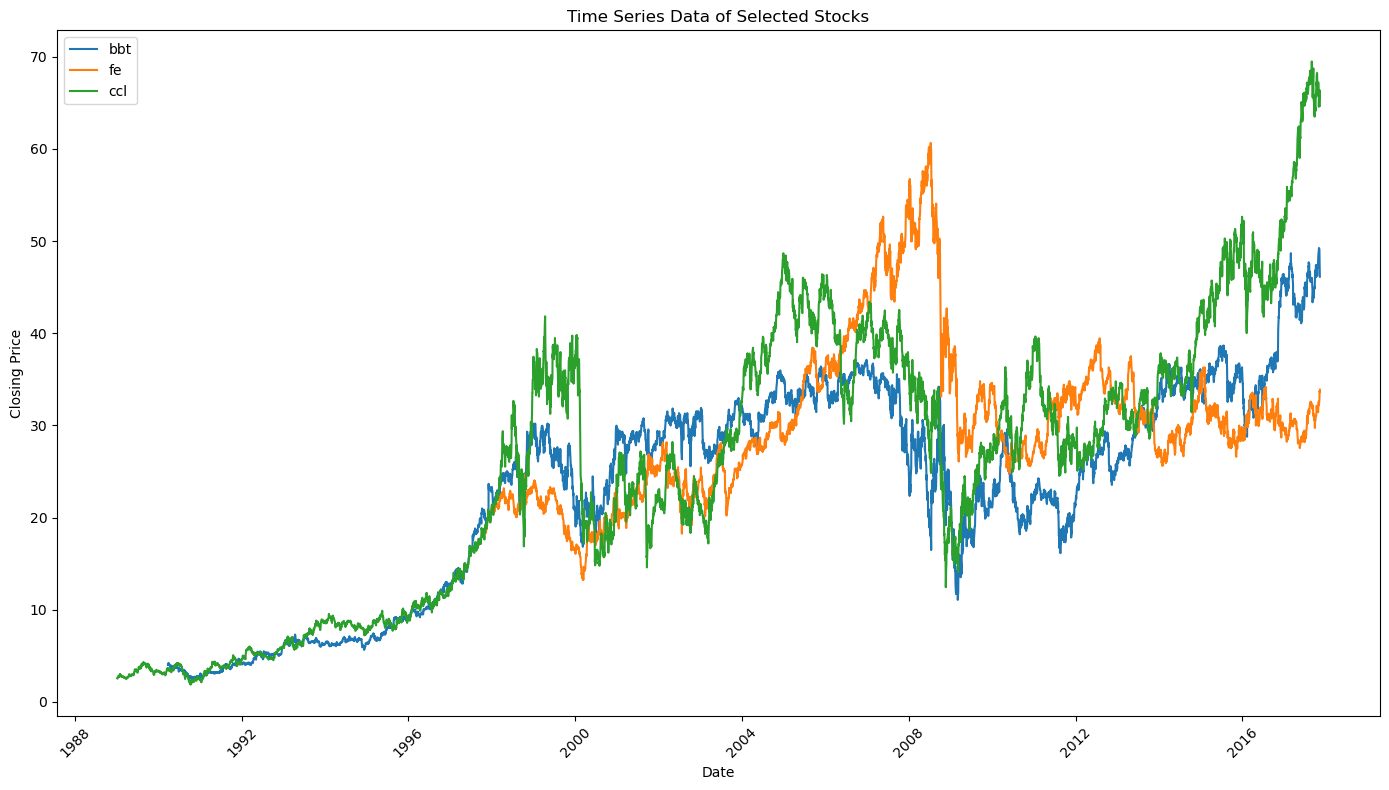

In [71]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Define the stocks to plot, excluding the specified ones
files = {
    'bbt': 'dataset/stock_csv/bbt.us.csv',
    'fe': 'dataset/stock_csv/fe.us.csv',
    'ccl': 'dataset/stock_csv/ccl.us.csv',
    # Add other stocks here if you want more included in the plot
}

# Initialize a plot
plt.figure(figsize=(14, 8))

# Plot each stock's time series data
for label, file_path in files.items():
    stock_data = pd.read_csv(file_path)
    
    # Convert 'Date' to datetime format and sort by date
    stock_data['Date'] = pd.to_datetime(stock_data['Date'])
    stock_data = stock_data.sort_values('Date')
    
    # Plot the data if 'Close' column exists
    if 'Close' in stock_data.columns:
        plt.plot(stock_data['Date'], stock_data['Close'], label=label)

# Format the plot
plt.title("Time Series Data of Selected Stocks")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()



In [34]:
import itertools
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load your data (replace 'your_data.csv' with your actual file path)
data = pd.read_csv('summary_statistics_2015_2017.csv')
data.dropna(inplace=True)

# Select numeric columns only
numeric_data = data.select_dtypes(include=[float, int])

# Standardize the numeric features
scaler = StandardScaler()
data_scaled = scaler.fit_transform(numeric_data)

# Generate combinations of three features
feature_combinations = list(itertools.combinations(range(data_scaled.shape[1]), 3))

# Dictionary to store silhouette scores
scores = {}

# Loop through each combination and calculate the silhouette score
for combo in feature_combinations:
    # Select subset of features
    selected_data = data_scaled[:, combo]
    
    # Perform K-means clustering
    kmeans = KMeans(n_clusters=5, random_state=42)
    clusters = kmeans.fit_predict(selected_data)
    
    # Calculate silhouette score
    score = silhouette_score(selected_data, clusters)
    
    # Store the score and feature indexes
    scores[combo] = score

# Find the best combination
best_combo = max(scores, key=scores.get)
best_score = scores[best_combo]

# Print results
print("Best feature combination (by index):", best_combo)
print("Best Silhouette Score:", best_score)
print("Feature names:", [numeric_data.columns[i] for i in best_combo])


Best feature combination (by index): (5, 7, 8)
Best Silhouette Score: 0.9983455964153974
Feature names: ['MA-10_75th', 'EMA_50th', 'EMA_75th']


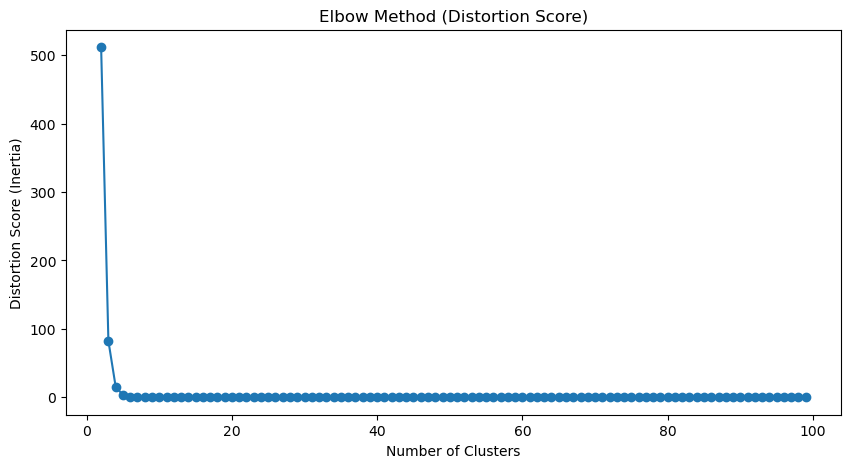

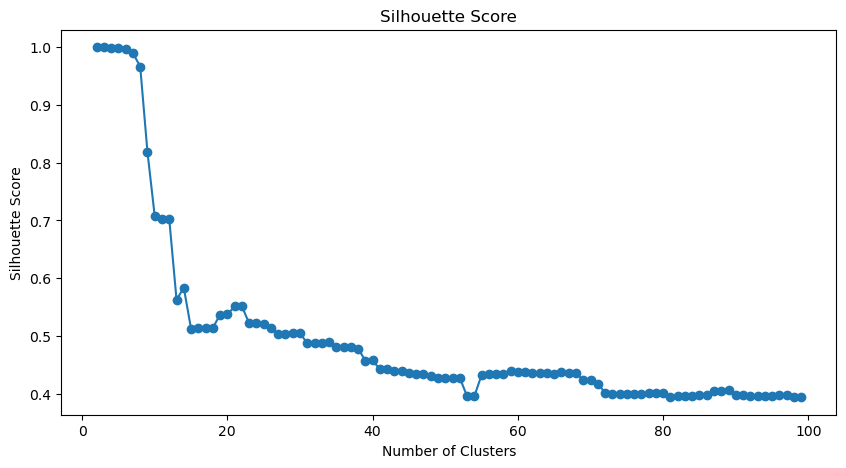

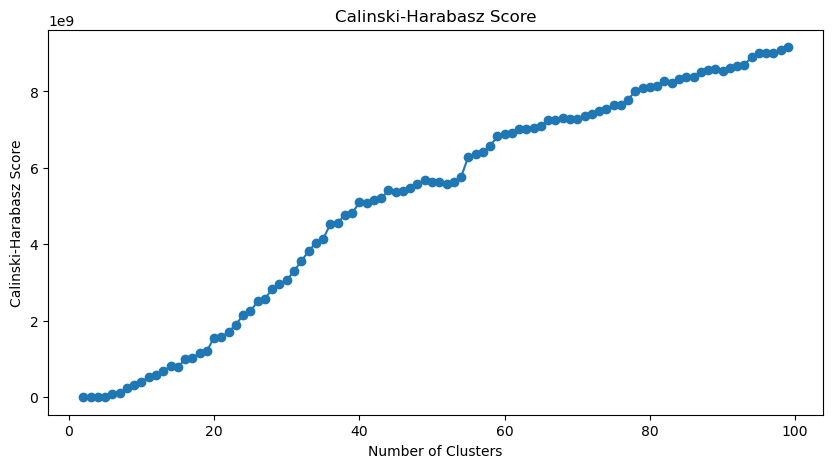

In [49]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt

# Load your data (replace 'dataset/stock_clusters.csv' with the actual path)
data = pd.read_csv('dataset/stock_clusters.csv')

# Select the features for clustering
selected_features = ['MA-10_75th', 'EMA_50th', 'EMA_75th']
data_selected = data[selected_features]

# Standardize the selected features
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_selected)

# Define a smaller range for clusters to test (to better observe the peak)
cluster_range = range(2, 100)  # Adjust the range based on observations

# Initialize lists for scores
distortions = []
silhouette_scores = []
calinski_harabasz_scores = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    labels = kmeans.labels_
    
    # Calculate Distortion Score (Sum of Squared Distances to closest center)
    distortions.append(kmeans.inertia_)
    
    # Calculate Silhouette Score (note: not ideal for k=1 or very high k values)
    if k > 1:
        silhouette_avg = silhouette_score(data_scaled, labels)
        silhouette_scores.append(silhouette_avg)
    
    # Calculate Calinski-Harabasz Score
    if k > 1:
        calinski_harabasz = calinski_harabasz_score(data_scaled, labels)
        calinski_harabasz_scores.append(calinski_harabasz)

# Plot Distortion Score (Elbow Method)
plt.figure(figsize=(10, 5))
plt.plot(cluster_range, distortions, marker='o')
plt.title("Elbow Method (Distortion Score)")
plt.xlabel("Number of Clusters")
plt.ylabel("Distortion Score (Inertia)")
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(10, 5))
plt.plot(range(2, 100), silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

# Plot Calinski-Harabasz Score
plt.figure(figsize=(10, 5))
plt.plot(range(2, 100), calinski_harabasz_scores, marker='o')
plt.title("Calinski-Harabasz Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Calinski-Harabasz Score")
plt.show()
